# 1- Clasificación de data con Arboles de decision


### Paso 1 - Importo los datos

In [2]:
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_excel('/content/drive/MyDrive/analitica/Travel_Data.xlsx',sheet_name=0)
score = pd.read_excel('/content/drive/MyDrive/analitica/Travel_Data.xlsx',sheet_name=1)
print(data)
print(score)


    College CreditCard  FoodSpend  Income  TravelSpend
0       Yes        Yes    5472.43   49150       827.40
1        No        Yes    9130.73   47806       863.55
2        No        Yes    4450.67   46050      1180.05
3        No        Yes    5020.72   42600       755.70
4        No        Yes    3408.11   52092       851.40
..      ...        ...        ...     ...          ...
495     Yes         No    3787.29   65982      2058.75
496      No         No    6460.84   57274      3852.90
497      No         No    3585.86   42250      2251.95
498     Yes         No    1833.95   60248      2000.25
499      No         No    6205.97   58520      3667.50

[500 rows x 5 columns]
  College  FoodSpend  Income  TravelSpend
0      No    2892.90   65982       2151.6
1     Yes    6017.66   53986       2002.5


### Paso 2 - Limpieza de datos

In [5]:
data.shape

(500, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   College      500 non-null    object 
 1   CreditCard   500 non-null    object 
 2   FoodSpend    500 non-null    float64
 3   Income       500 non-null    int64  
 4   TravelSpend  500 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 19.7+ KB


In [7]:
# Elimino las filas donde TravelSpend está vacío
XD = data.dropna(subset=['TravelSpend'])

In [8]:
XD

,College,CreditCard,FoodSpend,Income,TravelSpend
0,Yes,Yes,5472.43,49150,827.40
1,No,Yes,9130.73,47806,863.55
2,No,Yes,4450.67,46050,1180.05
3,No,Yes,5020.72,42600,755.70
4,No,Yes,3408.11,52092,851.40
...,...,...,...,...,...
495,Yes,No,3787.29,65982,2058.75
496,No,No,6460.84,57274,3852.90
497,No,No,3585.86,42250,2251.95
498,Yes,No,1833.95,60248,2000.25


In [9]:
XD.shape

(500, 5)

In [10]:
data[['College', 'CreditCard']] = data[['College', 'CreditCard']].replace({'Yes': 1, 'No': 0}).astype(int)
score[['College']] = score[['College']].replace({'Yes': 1, 'No': 0}).astype(int)

/tmp/ipython-input-3147946138.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[['College', 'CreditCard']] = data[['College', 'CreditCard']].replace({'Yes': 1, 'No': 0}).astype(int)
/tmp/ipython-input-3147946138.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  score[['College']] = score[['College']].replace({'Yes': 1, 'No': 0}).astype(int)


###Escoger las variables que voy a utilizar

In [11]:
XD = XD[['College', 'Income', 'TravelSpend', 'FoodSpend']]
XD['College'] = XD['College'].replace({'Yes': 1, 'No': 0}).astype(int)

/tmp/ipython-input-3421555863.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  XD['College'] = XD['College'].replace({'Yes': 1, 'No': 0}).astype(int)
/tmp/ipython-input-3421555863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XD['College'] = XD['College'].replace({'Yes': 1, 'No': 0}).astype(int)


In [12]:
yd = data['CreditCard'].dropna()

In [13]:
yd

,CreditCard
0,1
1,1
2,1
3,1
4,1
...,...
495,0
496,0
497,0
498,0


### Paso 3 - Construir modelo de arboles de decisión

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

In [15]:
## Creamos la variable que aloja el modelo

DTModel = DecisionTreeClassifier(criterion='gini', max_depth=4)

In [16]:
## Entreno el modelo
DTModel.fit(XD,yd)

DecisionTreeClassifier(max_depth=4)

### Paso 4 - Testeamos el modelo y construimos las métricas de evaluación

In [17]:
ydPred = DTModel.predict(XD)

In [18]:
## Creo la matriz de confusion
cm = confusion_matrix(yd, ydPred)

In [19]:
## Extraigo los valores de la matriz de confusion
VN=cm[0,0] ; FP=cm[0,1] ; FN=cm[1,0] ; VP=cm[1,1]

In [20]:
## Metricas de evaluacion del modelo
exactitud=(VP+VN)/(VP+VN+FP+FN)
sensibilidad=VP/(VP+FN)
especificidad=VN/(VN+FP)
error=1-exactitud
precision=VP/(VP+FP)

In [21]:
## Ejemplo de la impresión de las metricas de evaluacion
print(f'La exactitud del modelo es: {exactitud:.2%}')
print(f'La sensibilidad del modelo es: {sensibilidad:.2%}')
print(f'La especificidad del modelo es: {especificidad:.2%}')
print(f'La tasa de error del modelo es: {error:.2%}')
print(f'La precision del modelo es: {precision:.2%}')

La exactitud del modelo es: 89.80%
La sensibilidad del modelo es: 73.25%
La especificidad del modelo es: 97.38%
La tasa de error del modelo es: 10.20%
La precision del modelo es: 92.74%


### Paso 5 - Gráfico del Arbol de decisión

In [22]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

In [23]:
var = ['College', 'Income', 'TravelSpend', 'FoodSpend']
dot_data = StringIO()

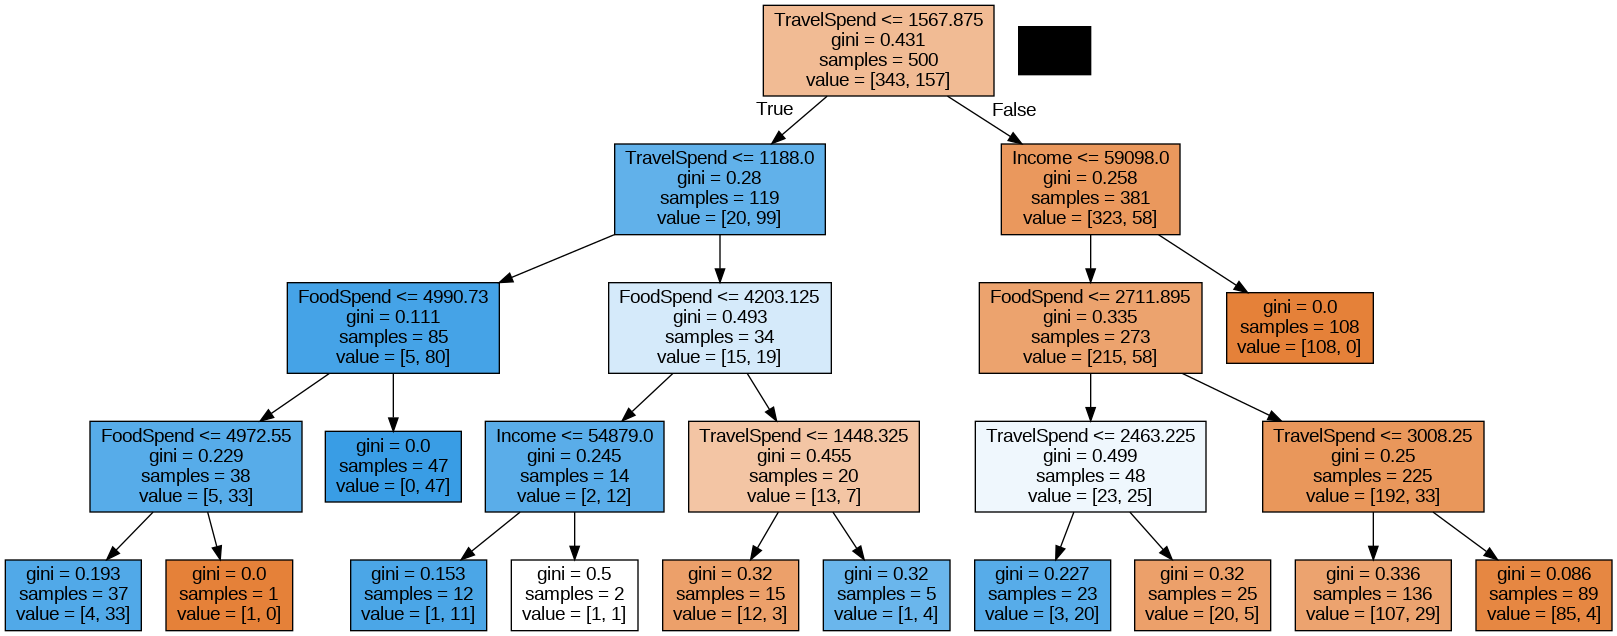

In [24]:
## Generamos el grafico
export_graphviz(DTModel,
                out_file=dot_data,
                feature_names=var,
                filled = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [25]:
graph.write_png('arbol.png')

True

In [32]:
DTModel.classes_

array([0, 1])

In [35]:
XDGener=score[['College', 'Income', 'TravelSpend', 'FoodSpend']]

,College,Income,TravelSpend,FoodSpend
0,0,65982,2151.6,2892.90
1,1,53986,2002.5,6017.66


In [34]:
# Nuevos clientes
ydPred = DTModel.predict(XDGener)
ydPred

array([0, 0])

**Preguntas**
1. Llevar a cabo la descripción de cada una de las variables que conforman el modelo.

College: Indica si la persona posee un título universitario (valor binario: “Sí” o “No”).

Credit Card: Señala si la persona presenta deudas con tarjetas de crédito (valor binario: “Sí” o “No”).

Food Spend: Monto total del gasto familiar anual en alimentos.

Income: Ingresos anuales totales del hogar.

Travel Spend: Gasto anual del hogar en productos y servicios relacionados con viajes.

2. Determinar las métricas de exactitud general, sensibilidad, especificidad.
La exactitud del modelo es: 89.80%
La sensibilidad del modelo es: 73.25%
La especificidad del modelo es: 97.38%

La exactitud del modelo es del 89.80%, lo que significa que, de cada 100 usuarios evaluados, casi 90 son clasificados correctamente respecto a si tienen o no deudas con tarjeta de crédito. Este indicador refleja un rendimiento confiable a nivel general, ya que integra tanto los aciertos en la detección de clientes endeudados como de aquellos que sin obligaciones pendientes. Esto significa que la empresa podrá identificar con mayor precisión a los clientes más aptos para recibir sus ofertas, ya que, al no tener deudas, probablemente cuenten con mayor ingreso disponible para destinar a viajes en lugar de utilizarlo en el pago de obligaciones financieras. También, caso de que la agencia ofrezca servicios de financiación, el nivel de confianza en este modelo también resulta relevante, ya que permite identificar si los clientes se apalancan excesivamente en la deuda. Esto posibilita enfocar las ofertas y la propuesta de valor hacia ese segmento, o bien detectar a aquellos que presentan un nivel de endeudamiento elevado y que podrían no ser buenos candidatos para financiar, ya sea por un alto riesgo de falta de pago o porque probablemente tarden demasiado tiempo en cumplir con sus obligaciones.

La sensibilidad es de un 73.25%, lo que indica que el modelo identifica correctamente a aproximadamente 7 de cada 10 usuarios que realmente tienen deudas con tarjetas de crédito. Este valor sugiere que, aunque el modelo tiene una buena capacidad de detección, aún existe un 26.75% de usuarios endeudados que no son identificados (falsos negativos). En términos de negocio, esto implica que la agencia podría pasar por alto a un grupo relevante de clientes con deudas, lo que puede afectar decisiones relacionadas con ofertas, promociones o gestión de riesgo crediticio. Esto puede interpretarse de dos formas. Por un lado, si la empresa busca aprovechar la financiación como una oportunidad de negocio, podría estar dejando pasar a una parte de los usuarios que sí podrían beneficiarse de estos servicios, perdiendo así potenciales ventas. Por otro lado, también existe el riesgo de no identificar a clientes que actualmente tienen deudas y que, por falta de recursos disponibles, no estarían en condiciones de contratar un viaje, lo que podría ocasionar pérdidas de tiempo y dinero para la empresa.

La especificidad del modelo es de 97.38%, lo que demuestra que es muy preciso al identificar a usuarios que no tienen deudas con tarjeta de crédito. Esto se traduce en un bajo porcentaje de falsos positivos, reduciendo el riesgo de que clientes sin deudas sean erróneamente clasificados como endeudados. Para la agencia, este comportamiento minimiza la posibilidad de restringir o condicionar innecesariamente el acceso de clientes solventes a ciertos productos o beneficios.

En conjunto, el modelo muestra un claro sesgo hacia la precisión en la identificación de usuarios sin deudas, lo que es positivo para evitar pérdidas por clasificaciones incorrectas en este grupo.

3. De acuerdo con los nuevos clientes en la base de datos Travel_Score, indicar cuál es la probabilidad de que cada uno de estos dos clientes tenga deudas con tarjetas de crédito.

Cliente 1: 0%
Cliente 2: 4.49%

4. Indicar cuáles son las reglas de los nodos puros.

If TravelSpend <= 1567.875 and TravelSpend <=1188 and FoodSpend <= 4990.73 and FoodSpend > 49772.55, then 0

If TravelSpend <= 1567.875 and TravelSpend <=1188 and FoodSpend > 4990.73, then 100

If TravelSpend > 1567.875 and Income > 59098, then 0

5. Determinar las reglas para los dos nuevos clientes de la hoja Travel_Score.

If TravelSpend > 1567.875 and Income > 59098, then 0

If TravelSpend > 1567.875 and Income <= 59098.0 and FoodSpend > 2711.895 and TravelSpend <= 3008.25, then 4.49
